In [50]:
PJME_data = pd.read_csv("datasets/PJME_hourly.csv")
PJME_data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [51]:
PJME_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [52]:
PJME_data.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [53]:
PJME_data.shape

(145366, 2)

In [54]:
PJME_data["Datetime"] = pd.to_datetime(PJME_data["Datetime"])

In [55]:
PJME_data["Datetime"].dtype

dtype('<M8[us]')

In [56]:
PJME_data = PJME_data.sort_values("Datetime")
PJME_data = PJME_data.reset_index(drop=True)

In [57]:
PJME_data.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [58]:
PJME_data.tail()

,Datetime,PJME_MW
145361,2018-08-02 20:00:00,44057.0
145362,2018-08-02 21:00:00,43256.0
145363,2018-08-02 22:00:00,41552.0
145364,2018-08-02 23:00:00,38500.0
145365,2018-08-03 00:00:00,35486.0


In [59]:
# Sort electricity demand records in chronological order
# so that past observations always occur before future observations
PJME_data = PJME_data.sort_values("Datetime").reset_index(drop=True)

In [60]:
PJME_data["Datetime"].duplicated().sum()

np.int64(4)

In [61]:
PJME_data = PJME_data.drop_duplicates(
    subset="Datetime",
    keep="first"
)

In [62]:
PJME_data["Datetime"].duplicated().sum()

np.int64(0)

In [63]:
#Check Missing Timestamps

In [64]:
PJME_data["Datetime"].diff().value_counts().head(10)

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
Name: count, dtype: int64

In [65]:
# Find timestamps where the gap is greater than 1 hour
missing_points = PJME_data[
    PJME_data["Datetime"].diff() > pd.Timedelta(hours=1)
]

print(missing_points[["Datetime"]])

                  Datetime
2306   2002-04-07 04:00:00
7176   2002-10-27 03:00:00
11040  2003-04-06 04:00:00
15910  2003-10-26 03:00:00
19774  2004-04-04 04:00:00
24812  2004-10-31 03:00:00
28508  2005-04-03 04:00:00
33546  2005-10-30 03:00:00
37242  2006-04-02 04:00:00
42280  2006-10-29 03:00:00
45472  2007-03-11 04:00:00
51182  2007-11-04 03:00:00
54206  2008-03-09 04:00:00
59916  2008-11-02 03:00:00
62940  2009-03-08 04:00:00
68650  2009-11-01 03:00:00
71842  2010-03-14 04:00:00
77552  2010-11-07 03:00:00
78341  2010-12-10 01:00:00
80575  2011-03-13 04:00:00
86285  2011-11-06 03:00:00
89309  2012-03-11 04:00:00
95019  2012-11-04 03:00:00
98043  2013-03-10 04:00:00
103753 2013-11-03 03:00:00
106777 2014-03-09 04:00:00
115513 2015-03-08 04:00:00
124417 2016-03-13 04:00:00
133153 2017-03-12 04:00:00
141889 2018-03-11 04:00:00


In [66]:
# Create the complete expected hourly timestamp range
full_range = pd.date_range(
    start=PJME_data["Datetime"].min(),
    end=PJME_data["Datetime"].max(),
    freq="h"
)

# Find timestamps that are expected but missing
missing_timestamps = full_range.difference(
    PJME_data["Datetime"]
)

print("Number of missing timestamps:", len(missing_timestamps))
print(missing_timestamps)

Number of missing timestamps: 30
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00',
               '2011-11-06 02:00:00', '2012-03-11 03:00:00',
               '2012-11-04 02:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2015-03-08 03:00:00', '2016-03-13 03:00:00',
               '2017-03-12 03:00:00', '2018-03-11 03:00:00'],
              dtype='datetime64[us]', freq=None)


In [67]:
# Set Datetime as index
PJME_data = PJME_data.set_index("Datetime")

# Insert all missing hourly timestamps
PJME_data = PJME_data.reindex(full_range)

# Restore index name
PJME_data.index.name = "Datetime"

In [68]:
print(PJME_data.isnull().sum())

PJME_MW    30
dtype: int64


In [69]:
# Fill missing electricity demand values using time-based interpolation
PJME_data["PJME_MW"] = PJME_data["PJME_MW"].interpolate(
    method="time"
)

In [70]:
print(PJME_data["PJME_MW"].isnull().sum())

0


In [71]:
print(
    PJME_data.index.to_series().diff().value_counts().head()
)

Datetime
0 days 01:00:00    145391
Name: count, dtype: int64


#### The PJM dataset contains 30 two-hour intervals, indicating 30 missing hourly timestamps. We will restore those timestamps and interpolate their electricity-demand values.

In [72]:
# Check for duplicate timestamps
duplicate_count = PJME_data.index.duplicated().sum()

print("Duplicate timestamps:", duplicate_count)

Duplicate timestamps: 0


In [73]:
# Check missing values in every column
print(PJME_data.isnull().sum())

PJME_MW    0
dtype: int64


In [74]:
print(PJME_data["PJME_MW"].describe())

count    145392.000000
mean      32078.927988
std        6464.283814
min       14544.000000
25%       27571.000000
50%       31420.000000
75%       35647.000000
max       62009.000000
Name: PJME_MW, dtype: float64


In [75]:
# Calculate first quartile
Q1 = PJME_data["PJME_MW"].quantile(0.25)

# Calculate third quartile
Q3 = PJME_data["PJME_MW"].quantile(0.75)

# Calculate interquartile range
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 27571.0
Q3: 35647.0
IQR: 8076.0


In [76]:
# Calculate lower and upper outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 15457.0
Upper Bound: 47761.0


In [77]:
# Identify observations outside the IQR boundaries
outliers = PJME_data[
    (PJME_data["PJME_MW"] < lower_bound) |
    (PJME_data["PJME_MW"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 3460


In [78]:
outliers.head(20)

,PJME_MW
Datetime,
2002-06-11 16:00:00,48426.0
2002-06-11 17:00:00,48968.0
2002-06-11 18:00:00,48565.0
2002-06-12 15:00:00,47852.0
2002-06-24 13:00:00,48937.0
2002-06-24 14:00:00,50207.0
2002-06-24 15:00:00,50783.0
2002-06-24 16:00:00,51148.0
2002-06-24 17:00:00,51137.0


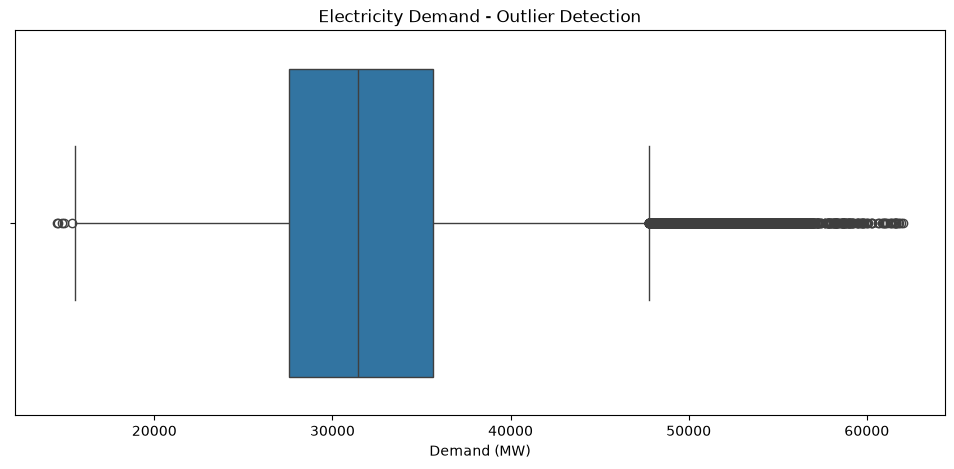

In [79]:
# outliers
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=PJME_data["PJME_MW"]
)

plt.title("Electricity Demand - Outlier Detection")
plt.xlabel("Demand (MW)")

plt.savefig(
    "electricity_demand_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
print(PJME_data.head())

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


In [81]:
# hour
# Extract hour of the day
PJME_data["Hour"] = PJME_data.index.hour

In [82]:
# Extract day of the month
PJME_data["Day"] = PJME_data.index.day

In [83]:
# Extract ISO calendar week
PJME_data["Week"] = (
    PJME_data.index.isocalendar().week.astype(int)
)

In [84]:
# Extract month number
PJME_data["Month"] = PJME_data.index.month

In [85]:
# Extract day of the week
# Monday = 0 and Sunday = 6
PJME_data["DayOfWeek"] = PJME_data.index.dayofweek

In [86]:
# Create weekend indicator
# 0 is Weekday
# 1 is Weekend
PJME_data["IsWeekend"] = (
    PJME_data["DayOfWeek"] >= 5
).astype(int)

In [87]:
PJME_data[["Hour", "DayOfWeek", "IsWeekend"]].head(10)

,Hour,DayOfWeek,IsWeekend
Datetime,,,
2002-01-01 01:00:00,1,1,0
2002-01-01 02:00:00,2,1,0
2002-01-01 03:00:00,3,1,0
2002-01-01 04:00:00,4,1,0
2002-01-01 05:00:00,5,1,0
2002-01-01 06:00:00,6,1,0
2002-01-01 07:00:00,7,1,0
2002-01-01 08:00:00,8,1,0
2002-01-01 09:00:00,9,1,0


In [88]:
# Electricity demand from the previous hour
PJME_data["Lag_1"] = PJME_data["PJME_MW"].shift(1)

In [89]:
# Electricity demand from 24 hours earlier
PJME_data["Lag_24"] = PJME_data["PJME_MW"].shift(24)

In [90]:
# Electricity demand from 48 hours earlier
PJME_data["Lag_48"] = PJME_data["PJME_MW"].shift(48)

In [91]:
# Electricity demand from the same hour one week earlier
PJME_data["Lag_168"] = PJME_data["PJME_MW"].shift(168)

In [92]:
# 24 hour rolling mean
# Calculate average demand over the previous 24 hours
PJME_data["Rolling_Mean_24"] = (
    PJME_data["PJME_MW"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

In [93]:
# Calculate average demand over the previous 168 hours
PJME_data["Rolling_Mean_168"] = (
    PJME_data["PJME_MW"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

In [94]:
# Measure demand variation over the previous 24 hours
PJME_data["Rolling_Std_24"] = (
    PJME_data["PJME_MW"]
    .shift(1)
    .rolling(window=24)
    .std()
)

In [95]:
# Measure demand variation over the previous 7 days
PJME_data["Rolling_Std_168"] = (
    PJME_data["PJME_MW"]
    .shift(1)
    .rolling(window=168)
    .std()
)

In [96]:
print(PJME_data.columns)

Index(['PJME_MW', 'Hour', 'Day', 'Week', 'Month', 'DayOfWeek', 'IsWeekend',
       'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168', 'Rolling_Mean_24',
       'Rolling_Mean_168', 'Rolling_Std_24', 'Rolling_Std_168'],
      dtype='str')


In [97]:
PJME_data.head(10)

,PJME_MW,Hour,Day,Week,Month,DayOfWeek,IsWeekend,Lag_1,Lag_24,Lag_48,Lag_168,Rolling_Mean_24,Rolling_Mean_168,Rolling_Std_24,Rolling_Std_168
Datetime,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,1,0,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,1,0,29265.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,1,0,28357.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,1,0,27899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 06:00:00,28654.0,6,1,1,1,1,0,28057.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 07:00:00,29308.0,7,1,1,1,1,0,28654.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 08:00:00,29595.0,8,1,1,1,1,0,29308.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 09:00:00,29943.0,9,1,1,1,1,0,29595.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
print(PJME_data.isnull().sum())

PJME_MW               0
Hour                  0
Day                   0
Week                  0
Month                 0
DayOfWeek             0
IsWeekend             0
Lag_1                 1
Lag_24               24
Lag_48               48
Lag_168             168
Rolling_Mean_24      24
Rolling_Mean_168    168
Rolling_Std_24       24
Rolling_Std_168     168
dtype: int64


In [100]:
# Remove initial rows created by lag and rolling features
PJME_data = PJME_data.dropna()

In [101]:
print(PJME_data.isnull().sum())

PJME_MW             0
Hour                0
Day                 0
Week                0
Month               0
DayOfWeek           0
IsWeekend           0
Lag_1               0
Lag_24              0
Lag_48              0
Lag_168             0
Rolling_Mean_24     0
Rolling_Mean_168    0
Rolling_Std_24      0
Rolling_Std_168     0
dtype: int64


In [102]:
print("Final Phase 2 shape:", PJME_data.shape)

Final Phase 2 shape: (145224, 15)


In [103]:
# Remove rows created by lag and rolling calculations
PJME_data = PJME_data.dropna()

# Reset the index after removing rows
PJME_data = PJME_data.sort_index()

In [104]:
print(PJME_data.isnull().sum())

PJME_MW             0
Hour                0
Day                 0
Week                0
Month               0
DayOfWeek           0
IsWeekend           0
Lag_1               0
Lag_24              0
Lag_48              0
Lag_168             0
Rolling_Mean_24     0
Rolling_Mean_168    0
Rolling_Std_24      0
Rolling_Std_168     0
dtype: int64


In [105]:
print("Final Phase 2 shape:", PJME_data.shape)

Final Phase 2 shape: (145224, 15)


In [107]:
time_diff = PJME_data.index.to_series().diff()

print(time_diff.value_counts().head())

Datetime
0 days 01:00:00    145223
Name: count, dtype: int64


In [108]:
print(PJME_data.columns.tolist())

['PJME_MW', 'Hour', 'Day', 'Week', 'Month', 'DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Mean_168', 'Rolling_Std_24', 'Rolling_Std_168']


In [109]:
print(PJME_data.dtypes)

PJME_MW             float64
Hour                  int32
Day                   int32
Week                  int64
Month                 int32
DayOfWeek             int32
IsWeekend             int64
Lag_1               float64
Lag_24              float64
Lag_48              float64
Lag_168             float64
Rolling_Mean_24     float64
Rolling_Mean_168    float64
Rolling_Std_24      float64
Rolling_Std_168     float64
dtype: object


In [110]:
print(
    "Infinite values:",
    np.isinf(PJME_data.select_dtypes(include=np.number)).sum().sum()
)

Infinite values: 0


In [111]:
print(PJME_data["PJME_MW"].describe())

count    145224.000000
mean      32078.418306
std        6466.681191
min       14544.000000
25%       27569.000000
50%       31419.000000
75%       35647.000000
max       62009.000000
Name: PJME_MW, dtype: float64


In [113]:
import os

os.makedirs("processed_data", exist_ok=True)

PJME_data.to_csv(
    "processed_data/PJME_phase2_preprocessed.csv"
)

print("Phase 2 dataset saved successfully.")

Phase 2 dataset saved successfully.
